Build an Image Classifier with Python


In [3]:
#Here we load the Mnist data from Keras
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
#get an idea of shape of train data
x_train.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


(60000, 28, 28)

8


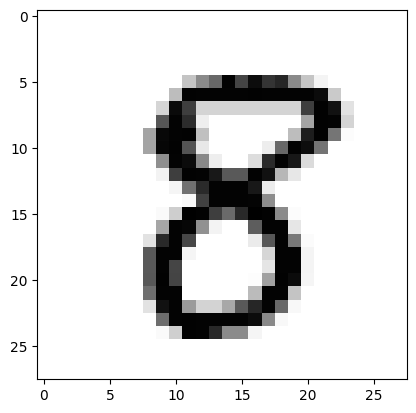

In [4]:
#Here we preview an element of the data
import matplotlib.pyplot as plt
image_index = 333
print(y_train[image_index])
plt.imshow(x_train[image_index], cmap='Greys')

In [7]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print('Number of images in x_train', x_train.shape[0])
print('Number of images in x_test', x_test.shape[0])

x_train shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))


In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9763 - loss: 0.0740
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9787 - loss: 0.0655
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9782 - loss: 0.0691
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9802 - loss: 0.0613
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.9815 - loss: 0.0571
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9818 - loss: 0.0552
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9827 - loss: 0.0520
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9819 - loss: 0.0528
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9844 - loss: 0.0497
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - accuracy: 0.9835 - loss: 0.0494
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9838 - loss: 0.0476
Epoch 12

In [14]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9788 - loss: 0.0712


[0.06149008125066757, 0.982200026512146]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
5


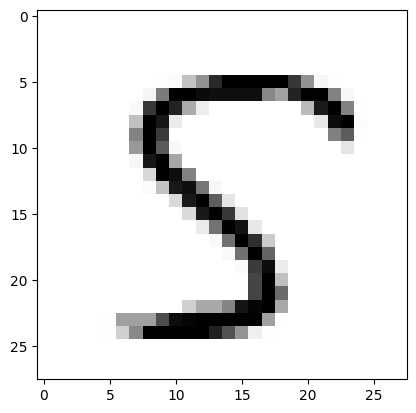

In [19]:
image_index = 333
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())

TypeError: Image data of dtype object cannot be converted to float

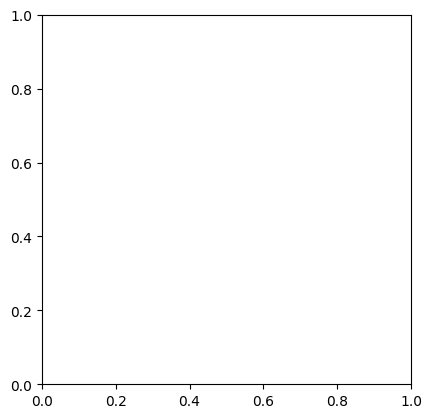

In [23]:
#Previewing the downloaded image
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
im = cv2.imread("last.PNG")
# Show image
plt.imshow(im, cmap="gray"), plt.axis("off")
plt.show()

In [ ]:
im.shape

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
img = image.load_img("last.PNG", target_size=(28, 28), color_mode="grayscale")


In [ ]:
img_array = image.img_to_array(img)

In [ ]:
img_array.shape

In [ ]:
img_array = img_array[:,:,0]
img_array.shape

In [ ]:
plt.imshow(img_array, cmap="Greys")

In [ ]:
img_array = 1-img_array
plt.imshow(img_array, cmap="Greys")

Prediction on sample image


In [ ]:
plt.imshow(img_array, cmap="Greys")
pred = model.predict(img_array.reshape(1, 28, 28, 1))
print(pred.argmax())